<a href="https://colab.research.google.com/github/eacasas/algoritmosOptimizacion/blob/main/ActividadGuiada1_EfraimCasas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Actividad Guiada Algoritmos de Optimización 1

Nombre: Efraím Alberto Casas Herrera

Enlace: https://colab.research.google.com/drive/1Vbuq5H9WS-AteUS7Q-IqTV8EytDrKcvW?usp=sharing


https://github.com/eacasas/algoritmosOptimizacion

# Divide y vencerás

## Torres de Hanoi

In [ ]:
#Torres de Hanoi

def Torres_Hanoi(N, desde, hasta):
  #N: número de fichas
  #desde: número de poste
  #hasta: número hasta

  if N==1:
    print(f'Lleva la ficha desde {desde}, hasta {hasta}')
  else:
    Torres_Hanoi(N-1, desde, 6-desde-hasta)
    print(f'Lleva la ficha desde {desde}, hasta {hasta}')
    Torres_Hanoi(N-1, 6-desde-hasta,hasta )

In [ ]:
##Prueba
Torres_Hanoi(4,1,3)

Lleva la ficha desde 1, hasta 2
Lleva la ficha desde 1, hasta 3
Lleva la ficha desde 2, hasta 3
Lleva la ficha desde 1, hasta 2
Lleva la ficha desde 3, hasta 1
Lleva la ficha desde 3, hasta 2
Lleva la ficha desde 1, hasta 2
Lleva la ficha desde 1, hasta 3
Lleva la ficha desde 2, hasta 3
Lleva la ficha desde 2, hasta 1
Lleva la ficha desde 3, hasta 1
Lleva la ficha desde 2, hasta 3
Lleva la ficha desde 1, hasta 2
Lleva la ficha desde 1, hasta 3
Lleva la ficha desde 2, hasta 3


# Técnica Voráz

## Cambio de Monedas

In [ ]:
def cambio_monedas(cantidad, sistema):
  #sistema = sistema.sort(reverse=True)
  # cantidad a cambiar
  # sistema: valor de las monedas diferente, ordenado de mayor valor a menor
  solucion = {}
  for  v in sistema:
    monedas = cantidad // v
    solucion[v] = monedas
    cantidad -= monedas * v
    if cantidad == 0:
      return solucion

In [ ]:
cambio_monedas(180, [50,20,10,5,2])

{50: 3, 20: 1, 10: 1}

# Vuelta Atrás (Backtracking)

## El problema de las N reinas

In [ ]:
#N Reinas - Vuelta Atrás()

#Verifica que en la solución parcial no hay amenzas entre reinas
################################################################
def es_prometedora(SOLUCION,etapa):
################################################################
  #print(SOLUCION)
  #Si la solución tiene dos valores iguales no es valida => Dos reinas en la misma fila
  for i in range(etapa+1):
    #print("El valor " + str(SOLUCION[i]) + " está " +  str(SOLUCION.count(SOLUCION[i])) + " veces")
    if SOLUCION.count(SOLUCION[i]) > 1:       
      return False
  
    #Verifica las diagonales
    for j in range(i+1, etapa +1 ):
      #print("Comprobando diagonal de " + str(i) + " y " + str(j))
      if abs(i-j) == abs(SOLUCION[i]-SOLUCION[j]) : return False
  return True

#Traduce la solución al tablero
################################################################
def escribe_solucion(S):
################################################################
  n = len(S)
  for x in range(n):
    print("")
    for i in range(n):
      if S[i] == x+1:
        print(" X " , end="")
      else:
        print(" - ", end="")



#Proceso principal de N-Reinas
################################################################
def reinas(N, solucion=[],etapa=0): 
################################################################
### ....
  if len(solucion) == 0:         # [0,0,0...]
    solucion = [0 for i in range(N) ]
  
  for i in range(1, N+1):
    solucion[etapa] = i
    if es_prometedora(solucion, etapa):
      if etapa == N-1:
        print(solucion)
      else:  
        reinas(N, solucion, etapa+1)
    else:
      None
  
  solucion[etapa] = 0



In [ ]:
# Prueba
reinas(4,solucion=[],etapa=0)

[2, 4, 1, 3]
[3, 1, 4, 2]


# Práctica Individual

## Puntos cercanos

In [ ]:
import numpy as np
import pandas as pd
import time
from numpy.random import default_rng

In [ ]:
# 

lista_1D = np.random.randint(0,100, size = 10)
display(lista_1D)

array([59,  9, 75, 63, 65, 72, 45, 84, 35, 86])

### 1. Solución fuerza bruta

En esta solución se realiza la comparación entre cada uno de los elementos de la lista. 

In [ ]:
def minDistanciaFB(lista_1D):
  distancias=[]
  for i in lista_1D:
    for j in lista_1D: 
      if i!=j:
        distancias.append((abs(i-j),(i,j)))

  return (min(distancias, key=lambda x: x[0]))

In [ ]:
minimo = minDistanciaFB(lista_1D)
print(f'los números mas cercanos son: {minimo[1]} con una distancia de: {minimo[0]}')

los números mas cercanos son: (63, 65) con una distancia de: 2


### Oreden de complejidad

El orden de complejidad del algoritmo es O(n^2)

### 2. Divide y vencerás 

Para la estrategía de divide y vencerás utilizaremos primero un oredenamiento QuiickSort(divide y vencerás) y luego realizaremos la comprobación de distancia entre números adyacentes. Con esto se espera reducir el Orden de complejidad promemedio.

In [ ]:
def partition(array, low, high):
 
    pivot = array[high] 
    i = low - 1 
    for j in range(low, high):
        if array[j] <= pivot:
          i = i + 1 
          (array[i], array[j]) = (array[j], array[i])
 
    # Swap the pivot element with the greater element specified by i
    (array[i + 1], array[high]) = (array[high], array[i + 1]) 
    # Return the position from where partition is done
    return i + 1

def quickSort(array, low, high):
    if low < high: 
       
        pi = partition(array, low, high) 
        # Recursive call on the left of pivot
        quickSort(array, low, pi - 1) 
        # Recursive call on the right of pivot
        quickSort(array, pi + 1, high)
 

def minDistanciaDV(lista_1D):

  quickSort(lista_1D,0,len(lista_1D)-1)
  min = 100000000
  for i in range(len(lista_1D)-1):
    if abs(lista_1D[i]-lista_1D[i-1]) < min:
      min=abs(lista_1D[i]-lista_1D[i-1])
      tupla = (lista_1D[i],lista_1D[i-1])
  
  return min, tupla




In [ ]:
minimoDV, tupla = minDistanciaDV(lista_1D)
print(lista_1D)
print(f'los números mas cercanos son: {tupla} con una distancia de: {minimoDV}')



[ 9 35 45 59 63 65 72 75 84 86]
los números mas cercanos son: (65, 63) con una distancia de: 2


### Orden de complejidad

El orden de complejidad de la solución utilizando Divide y Vencerás, está dado por el Orden de complejidad del  método de ordenamiento QuickSort mas el orden de complejidad de recorrer el arreglo:

O(O(Qs)+O(n))

El orden de complejidad de QuickSort en promedio es O(n log n) y el peor de los casos es 0(n^2). Entonces el orden de la función sería:

Promedio: O(n*logn + n) => O(n*logn): Cuasi lineal

Peor de los casos: O(n^2 +n) => O(n^2): Cuadrático (Esta caso es muy poco probable, para números aleatorios. porque el arreglo debe estar en en orden inverso)

# Pruebas

In [ ]:
rng = default_rng()
lista_1000 = rng.choice(4000, size=1000, replace=False)

display(lista_1000)

array([1269, 1844, 3207, 3169, 1642, 3293, 3450,  386, 1259,   46,  201,
       2874,  495, 3039, 3621, 3382, 2820, 2327, 1239, 2140, 2310, 3515,
       2513, 3263,  915, 3472, 1425, 2806, 3070,  312, 2212, 2354, 2543,
       2507, 3984,  500, 1605, 1548, 2781, 1250,  211,  891,  950, 2793,
       2125, 3555, 1544, 2288,  120, 3157,  303, 1190, 3871, 2188, 3247,
       3648, 3176, 1314, 3220, 3379,  535, 3125, 2104, 2412, 1993, 1332,
       3531, 1935, 1366, 3756,  330, 1740,  536,  982, 2226, 1573,  673,
       3171, 3036, 3879, 1852,  696, 1966, 1217, 1998, 1145, 2265, 3479,
       3163, 2669, 2243, 2066, 3830, 3538, 2368, 3935, 1147, 2133, 2698,
       3683, 3126, 1662, 2349, 2001, 1112,  901, 1157, 3290, 2785, 2810,
       2391, 1363, 1930,  239,  886,  550, 2261, 3509, 1002, 2773, 1137,
        769,  807, 2817, 3777, 3755, 2185, 1326,  672, 3173, 3273, 1000,
       2934,  630, 3331, 1837, 3219,  842, 2609, 2403, 2818, 2308, 3882,
       2931,    3, 3942, 3785,  728, 2868, 3139,   

In [ ]:
# con fuerza bruta y 1000 numeros
t0 = time.perf_counter()   
minimo = minDistanciaFB(lista_1000)
r= time.perf_counter()-t0
print(f'los números mas cercanos son: {minimo[1]} con una distancia de: {minimo[0]}')
print(f'tiempo: {r}')


los números mas cercanos son: (3450, 3451) con una distancia de: 1
tiempo: 1.1692779879999762


In [ ]:
 # con divide y vencerás 1000 números
t0 = time.perf_counter()   
minimoDV, tupla = minDistanciaDV(lista_1000)
r= time.perf_counter()-t0
print(f'los números mas cercanos son: {tupla} con una distancia de: {minimoDV}')
print(f'tiempo: {r}')

los números mas cercanos son: (8, 7) con una distancia de: 1
tiempo: 0.012335272000200348


### Prueba masiva para 10 muestras de cada método

A continuación se realizará una prueba con 10 muestras por cada método, y se guardarán los resultados en la lista "resultados" para posteriormente visualizar los resultados mediante la libreria Seaborn.

In [ ]:
#Para almacenar los resultados
resultados = pd.DataFrame(columns=['metodo','n','tiempo'])

#Para generar números aleatorios sin repetición
rng = default_rng()

#Se realizarán 10 muestras por cada método
for i in range(10):
  # Se genra la lista para ser probada con ambos métodos
  lista_1000 = rng.choice(4000, size=1000, replace=False)
    

  #Se llama el método de fuerza bruta: FB
  t0 = time.perf_counter() 
  minimo = minDistanciaFB(lista_1000)
  r= time.perf_counter()-t0
  new_row = {'metodo':'FB','n':i,'tiempo':r}
  resultados= resultados.append(new_row, ignore_index=True)


  #Se llama el método de Divide y Vencerás
  t0 = time.perf_counter() 
  minimoDV, tupla = minDistanciaDV(lista_1000)
  r= time.perf_counter()-t0
  new_row = {'metodo':'DV','n':i,'tiempo':r}
  resultados= resultados.append(new_row, ignore_index=True)



In [ ]:
display(resultados)

,metodo,n,tiempo
0,FB,0,1.219759
1,DV,0,0.004643
2,FB,1,0.993516
3,DV,1,0.005402
4,FB,2,1.031462
5,DV,2,0.004835
6,FB,3,1.068465
7,DV,3,0.004820
8,FB,4,0.934809
9,DV,4,0.005300


## Visualización de resultados

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

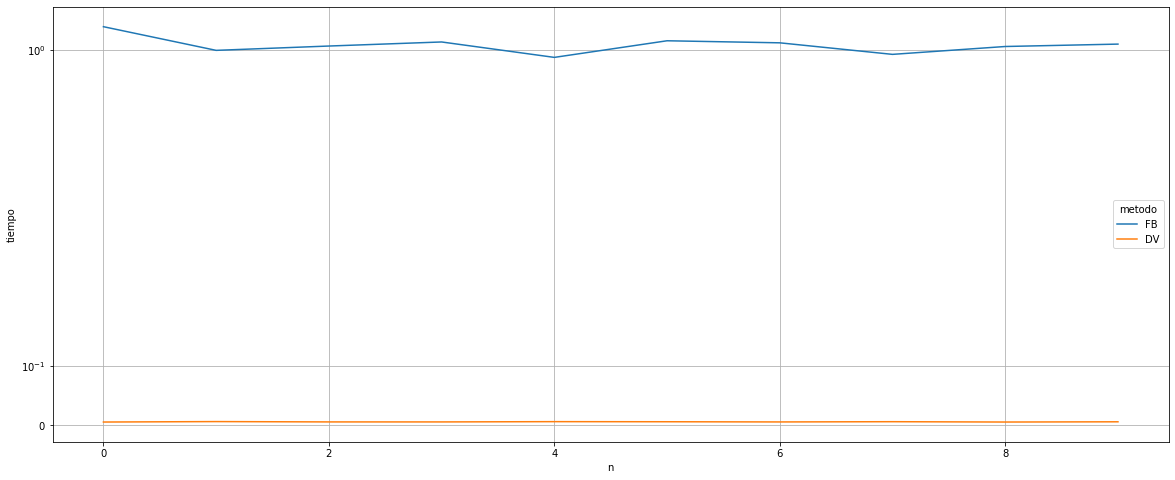

In [ ]:
f, ax = plt.subplots(figsize=(20, 8))
plt.xscale('linear')
plt.yscale('log')
ax.set_yscale('symlog', linthreshy=0.5)


ax.grid()

sns.lineplot(data = resultados,
             x ='n',
             y ='tiempo',
             hue='metodo',
             markers=True,
             dashes=False,
             ax=ax)

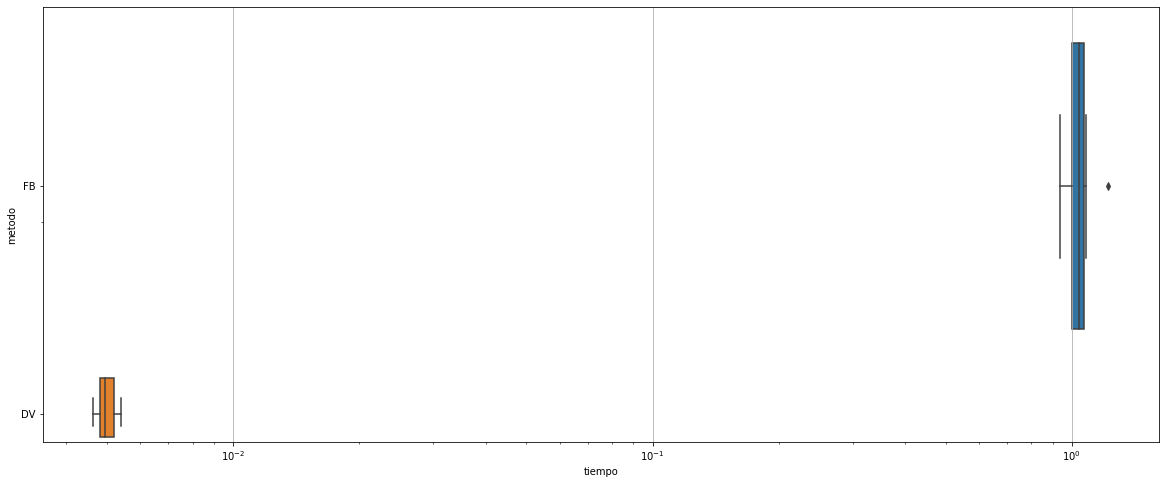

In [ ]:
f, ax = plt.subplots(figsize=(20, 8))
plt.xscale('log')
plt.yscale('linear')
ax.set_yscale('symlog', linthreshy=0.5)


ax.grid()

sns.boxplot(data=resultados, x='tiempo', y='metodo')

**Conclusión**: Como podemos ver el el tiempo de ejecicón de los números más cercanos es considerablemente menos en el método de divide y vencerás, en el cual se comienza por ordenar la lista y luego hacer la comparación entre los elementos más cercanos. 
El tiempo promedio para divide y vencerás está en torno a los 4 milisegundos y el tiempo para la solución de fuerza bruta está al rededor de un segundo.

### Distancias para 2D

Se establecen parejas de datos la fila 0 contiene las coordenadas en X y la fila 1 y contiene las coordenadas en Y

In [ ]:
lista_2D = np.random.randint(0,100, size = (2,10))
display(lista_2D)

array([[12, 64, 68, 57, 28, 93,  8, 30, 57, 96],
       [79, 81, 56, 63,  7, 35, 69, 71, 96,  3]])

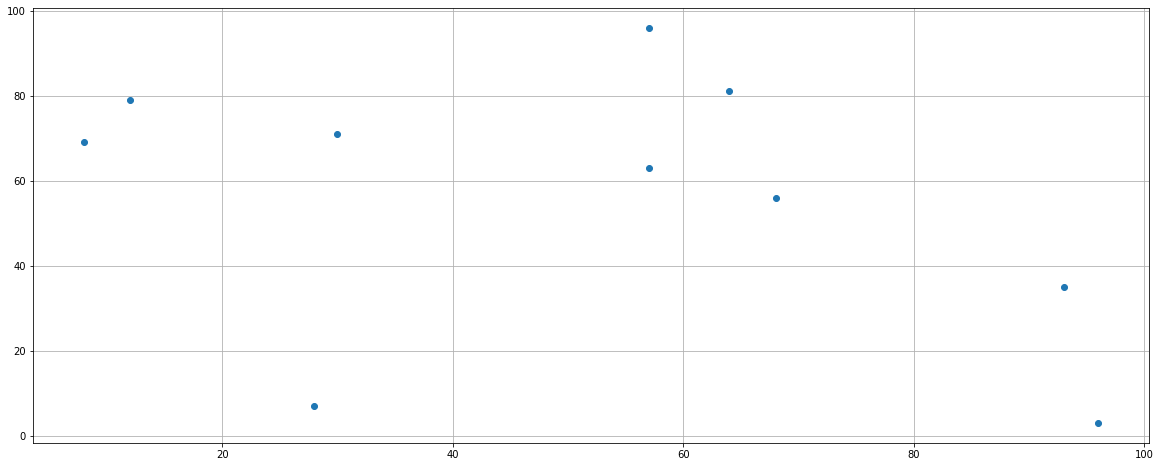

In [ ]:
plt.gcf().set_size_inches(20, 8)
plt.grid()
plt.scatter(lista_2D[0,:], lista_2D[1,:])

In [ ]:

def minDistanciaFB_2D(lista_2D):
  distancias=[]
  for i in range(len(lista_2D[0])):
    x1,y1 = lista_2D[:,i]
    #print(f'X: {x} Y:{y}')
    for j in range(len(lista_2D[0])):
      if i!=j:
        x2,y2 = lista_2D[:,j]
        distancia = np.sqrt((x1-x2)**2 + (y1-y2)**2)
        distancias.append((distancia, (x1,y1), (x2,y2)))

  return (min(distancias, key=lambda x: x[0]))



### Prueba

In [ ]:
cercanos = minDistanciaFB_2D(lista_2D)

print(f'los puntos mas cercanos son: {cercanos[1][:]} y {cercanos[2][:]} con una distancia de: {cercanos[0]}')



los puntos mas cercanos son: (12, 79) y (8, 69) con una distancia de: 10.770329614269007


### Visualización

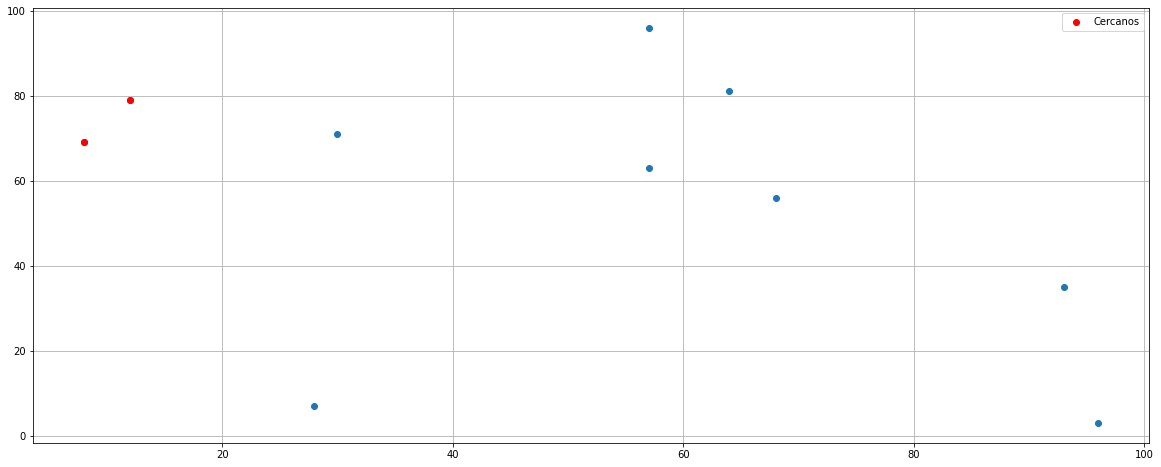

In [ ]:
plt.gcf().set_size_inches(20, 8)
plt.grid()
plt.scatter(lista_2D[0,:], lista_2D[1,:])
plt.scatter(cercanos[1][0], cercanos[1][1], color='red',label='Cercanos')
plt.scatter(cercanos[2][0], cercanos[2][1], color='red')
plt.legend(loc='best')
